## Cell 7 — Optuna trial summary

All 8 trials ranked by val F1. Include this table in your report.

In [11]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "datasets", "optuna", "shap",
                "torch", "scikit-learn", "matplotlib", "seaborn"], check=True)
print("✓ Packages installed")

✓ Packages installed


In [12]:
import os, json
import numpy as np
import pandas as pd
import torch
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
print("✓ Imports done")

✓ Imports done


In [13]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  WARNING: No GPU — training will be very slow.")

✓ Device: cuda
  GPU: Tesla T4


In [14]:
DATA_PATH    = "/kaggle/input/datasets/joepotter190/mental/merged_data.csv"
TEXT_COLUMN  = "clean_text"
LABEL_COLUMN = "label"
MODEL_NAME   = "mental/mental-bert-base-uncased"
NUM_CLASSES  = 5
MAX_LEN      = 200
SEED         = 42
OUTPUT_DIR   = "/kaggle/working/mentalbert"
FIGURES_DIR  = "/kaggle/working/figures"
LABEL_NAMES  = {
    0: "anxiety",
    1: "depression",
    2: "loneliness",
    3: "normal",
    4: "suicidal"
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✓ Config set")
print(f"  Model      : {MODEL_NAME}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Labels     : {LABEL_NAMES}")

✓ Config set
  Model      : mental/mental-bert-base-uncased
  Output dir : /kaggle/working/mentalbert
  Labels     : {0: 'anxiety', 1: 'depression', 2: 'loneliness', 3: 'normal', 4: 'suicidal'}


In [15]:
df = pd.read_csv(DATA_PATH)
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna(subset=[TEXT_COLUMN])
df = df.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN: "label"})
df["text"] = df["text"].astype(str)

print(f"✓ Loaded {len(df):,} samples")
print(f"  Columns: {list(df.columns)}")
print()
print("--- First row ---")
print(df.iloc[0])

✓ Loaded 477,856 samples
  Columns: ['text', 'label']

--- First row ---
text     feeling like ill never loving relationship kee...
label                                           loneliness
Name: 0, dtype: object


In [16]:
label_to_int = {name: idx for idx, name in LABEL_NAMES.items()}
df["label"]  = df["label"].map(label_to_int)

print("✓ Label conversion done")
print()
print("Label distribution:")
for idx, name in LABEL_NAMES.items():
    n = (df["label"] == idx).sum()
    print(f"  {idx} ({name}): {n:,} ({n/len(df)*100:.1f}%)")

✓ Label conversion done

Label distribution:
  0 (anxiety): 98,275 (20.6%)
  1 (depression): 97,663 (20.4%)
  2 (loneliness): 91,873 (19.2%)
  3 (normal): 95,044 (19.9%)
  4 (suicidal): 95,001 (19.9%)


In [17]:
# 80% train, 10% val, 10% test — stratified to preserve class ratios
df_temp, df_test  = train_test_split(df,      test_size=0.10,  stratify=df["label"],      random_state=SEED)
df_train, df_val  = train_test_split(df_temp, test_size=0.111, stratify=df_temp["label"], random_state=SEED)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"✓ Split done")
print(f"  Train : {len(df_train):,} (80%)")
print(f"  Val   : {len(df_val):,} (10%)")
print(f"  Test  : {len(df_test):,} (10%) — locked until final evaluation")

✓ Split done
  Train : 382,332 (80%)
  Val   : 47,738 (10%)
  Test  : 47,786 (10%) — locked until final evaluation


In [18]:
from huggingface_hub import login

# You'll be prompted to enter your token
# Get your token from: https://huggingface.co/settings/tokens
login()

In [19]:
print(f"Loading tokenizer for: {MODEL_NAME}")
print("Downloads from HuggingFace on first run (~500MB), then cached.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"✓ Tokenizer loaded — vocab size: {tokenizer.vocab_size:,}")
print()

# Demonstrate tokenization
example = "I haven't left my room in days, nothing feels worth it anymore"
tokens  = tokenizer.tokenize(example)
print(f"Example : '{example}'")
print(f"Tokens  : {tokens}")

Loading tokenizer for: mental/mental-bert-base-uncased
Downloads from HuggingFace on first run (~500MB), then cached.
✓ Tokenizer loaded — vocab size: 30,522

Example : 'I haven't left my room in days, nothing feels worth it anymore'
Tokens  : ['i', 'haven', "'", 't', 'left', 'my', 'room', 'in', 'days', ',', 'nothing', 'feels', 'worth', 'it', 'anymore']


In [20]:
class MentalHealthDataset(Dataset):
    """
    Wraps text + label data for the HuggingFace Trainer.
    Tokenization happens on-the-fly in __getitem__ to save memory.
    Each sample returns:
      - input_ids      : token IDs BERT reads
      - attention_mask : 1 for real tokens, 0 for padding
      - labels         : integer class (0-4)
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

print("✓ MentalHealthDataset class defined")

✓ MentalHealthDataset class defined


In [21]:
train_dataset = MentalHealthDataset(df_train["text"].tolist(), df_train["label"].tolist(), tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(df_val["text"].tolist(),   df_val["label"].tolist(),   tokenizer, MAX_LEN)
test_dataset  = MentalHealthDataset(df_test["text"].tolist(),  df_test["label"].tolist(),  tokenizer, MAX_LEN)

print(f"✓ Full datasets built")
print(f"  Train : {len(train_dataset):,}")
print(f"  Val   : {len(val_dataset):,}")
print(f"  Test  : {len(test_dataset):,}")

# Sanity check one sample
sample = train_dataset[0]
print()
print(f"  Sample keys         : {list(sample.keys())}")
print(f"  input_ids shape     : {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label               : {sample['labels']}")

✓ Full datasets built
  Train : 382,332
  Val   : 47,738
  Test  : 47,786

  Sample keys         : ['input_ids', 'attention_mask', 'labels']
  input_ids shape     : torch.Size([200])
  attention_mask shape: torch.Size([200])
  label               : 0


In [22]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_train["label"]),
    y=df_train["label"]
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("✓ Class weights computed:")
for i, (name, w) in enumerate(zip(LABEL_NAMES.values(), class_weights)):
    print(f"  {i} ({name}): {w:.4f}")

✓ Class weights computed:
  0 (anxiety): 0.9725
  1 (depression): 0.9786
  2 (loneliness): 1.0402
  3 (normal): 1.0056
  4 (suicidal): 1.0060


In [23]:
def compute_metrics(eval_pred):
    """Macro F1 — fair for imbalanced classes, doesn't let majority dominate."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, predictions, average="macro")}


class WeightedTrainer(Trainer):
    """
    HuggingFace Trainer with weighted cross-entropy loss.
    Rare classes are penalized more so the model doesn't ignore them.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=class_weights_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


print("✓ WeightedTrainer and compute_metrics defined")

✓ WeightedTrainer and compute_metrics defined


In [24]:
def model_init():
    """
    Fresh MentalBERT for each Optuna trial.
    Adds a linear head [768 → NUM_CLASSES] on top of BERT's [CLS] output.
    """
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )

print("✓ model_init defined")
print(f"  Will load: {MODEL_NAME}")
print(f"  Num labels: {NUM_CLASSES}")

✓ model_init defined
  Will load: mental/mental-bert-base-uncased
  Num labels: 5


In [25]:
def subsample(df, frac, seed=SEED):
    """Sample a fixed fraction per class to preserve class balance."""
    return df.groupby("label", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    ).reset_index(drop=True)

df_train_small = subsample(df_train, 0.15)
df_val_small   = subsample(df_val,   0.15)

train_dataset_search = MentalHealthDataset(
    df_train_small["text"].tolist(), df_train_small["label"].tolist(), tokenizer, MAX_LEN
)
val_dataset_search = MentalHealthDataset(
    df_val_small["text"].tolist(), df_val_small["label"].tolist(), tokenizer, MAX_LEN
)

print(f"✓ Optuna subset ready (15% of data)")
print(f"  Train subset : {len(train_dataset_search):,}")
print(f"  Val subset   : {len(val_dataset_search):,}")

✓ Optuna subset ready (15% of data)
  Train subset : 57,350
  Val subset   : 7,161


/tmp/ipykernel_57/1799010414.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("label", group_keys=False).apply(
/tmp/ipykernel_57/1799010414.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("label", group_keys=False).apply(


In [26]:
tuning_trainer = WeightedTrainer(
    model_init=model_init,
    args=TrainingArguments(
        output_dir=OUTPUT_DIR,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        seed=SEED,
        fp16=True,
        report_to="none",
        logging_steps=100,
    ),
    train_dataset=train_dataset_search,
    eval_dataset=val_dataset_search,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("✓ tuning_trainer ready")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

✓ tuning_trainer ready


In [27]:
def hp_space_fast(trial):
    """
    Only tune the 2 hyperparameters that matter most for BERT fine-tuning.
    Keeps Optuna fast without sacrificing much search quality.
    """
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "weight_decay" : trial.suggest_float("weight_decay", 0.0, 0.1),
    }

print("✓ hp_space_fast defined")
print("  Tuning: learning_rate, weight_decay")
print("  Fixed : batch_size=16, epochs=2, warmup_ratio=0.1")

✓ hp_space_fast defined
  Tuning: learning_rate, weight_decay
  Fixed : batch_size=16, epochs=2, warmup_ratio=0.1


In [28]:
print("Starting Optuna search — 2 trials × 2 epochs × 15% data ≈ 45 min")
print("─" * 55)

best_run = tuning_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space_fast,
    n_trials=2
)

print("\n=== OPTUNA SEARCH COMPLETE ===")
print(f"  Best val F1 : {best_run.objective:.4f}")
print("  Best hyperparameters:")
for k, v in best_run.hyperparameters.items():
    print(f"    {k}: {v}")

[I 2026-05-17 18:30:04,785] A new study created in memory with name: no-name-d25c924c-5bf3-43fc-bb00-8d8ce2660732


Starting Optuna search — 2 trials × 2 epochs × 15% data ≈ 45 min
───────────────────────────────────────────────────────


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

...

Epoch,Training Loss,Validation Loss,F1
1,0.950419,0.922327,0.637823
2,0.766348,0.927619,0.651492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== OPTUNA SEARCH COMPLETE ===
  Best val F1 : 0.6515
  Best hyperparameters:
    learning_rate: 3.6953958501474775e-05
    weight_decay: 0.044648967619087127


In [29]:
best_hp = best_run.hyperparameters

final_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "final"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=best_hp["learning_rate"],
    weight_decay=best_hp["weight_decay"],
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    seed=SEED,
    report_to="none",
    logging_steps=50,
)

final_trainer = WeightedTrainer(
    model=model_init(),
    args=final_args,
    train_dataset=train_dataset,     # full data
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Training final model on full data (~3 hours)...")
print(f"  learning_rate : {best_hp['learning_rate']:.2e}")
print(f"  weight_decay  : {best_hp['weight_decay']:.4f}")
print(f"  epochs        : 3")
print(f"  batch_size    : 16")
print("─" * 55)
final_trainer.train()
print("✓ Training complete.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

Training final model on full data (~3 hours)...
  learning_rate : 3.70e-05
  weight_decay  : 0.0446
  epochs        : 3
  batch_size    : 16
───────────────────────────────────────────────────────


Epoch,Training Loss,Validation Loss,F1
1,0.897317,0.868217,0.662870
2,0.759446,0.840161,0.678220
3,0.631149,0.863599,0.687226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✓ Training complete.


In [1]:
SAVED_MODEL_PATH = os.path.join(OUTPUT_DIR, "final_model")
final_trainer.model.save_pretrained(SAVED_MODEL_PATH)
tokenizer.save_pretrained(SAVED_MODEL_PATH)

print(f"✓ Model saved to: {SAVED_MODEL_PATH}")
print("To reload later:")
print(f"  model     = AutoModelForSequenceClassification.from_pretrained('{SAVED_MODEL_PATH}')")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{SAVED_MODEL_PATH}')")

NameError: name 'os' is not defined

=== VALIDATION SET RESULTS ===
              precision    recall  f1-score   support

     anxiety       0.81      0.83      0.82      9818
  depression       0.53      0.49      0.51      9756
  loneliness       0.77      0.82      0.80      9178
      normal       0.65      0.58      0.61      9495
    suicidal       0.66      0.73      0.69      9491

    accuracy                           0.69     47738
   macro avg       0.69      0.69      0.69     47738
weighted avg       0.69      0.69      0.69     47738



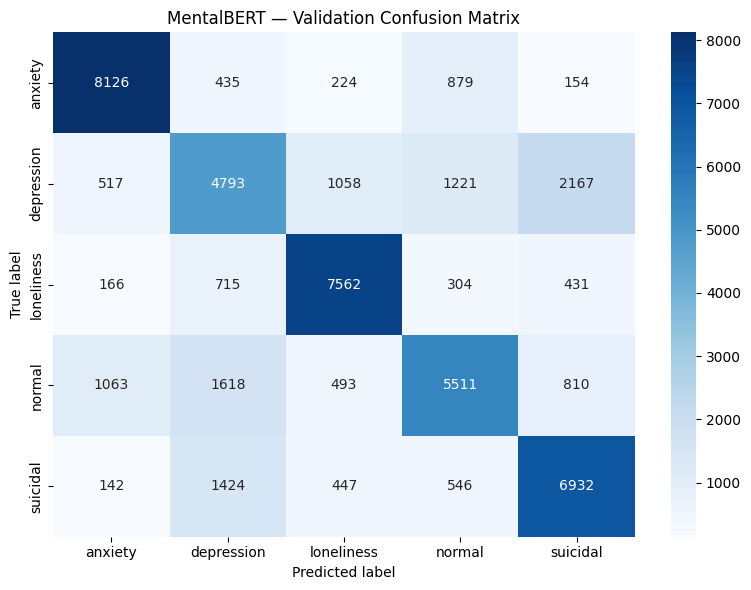

✓ Saved: /kaggle/working/figures/mentalbert_val_confusion_matrix.png


In [31]:
label_names_list = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]

def get_predictions(trainer, dataset):
    out = trainer.predict(dataset)
    return np.argmax(out.predictions, axis=-1), out.label_ids

def plot_confusion_matrix(y_true, y_pred, label_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✓ Saved: {save_path}")

val_preds, val_true = get_predictions(final_trainer, val_dataset)
print("=== VALIDATION SET RESULTS ===")
print(classification_report(val_true, val_preds, target_names=label_names_list))
plot_confusion_matrix(
    val_true, val_preds, label_names_list,
    "MentalBERT — Validation Confusion Matrix",
    os.path.join(FIGURES_DIR, "mentalbert_val_confusion_matrix.png")
)

=== FINAL TEST SET RESULTS ===
              precision    recall  f1-score   support

     anxiety       0.82      0.83      0.83      9828
  depression       0.53      0.48      0.50      9766
  loneliness       0.78      0.83      0.80      9187
      normal       0.65      0.58      0.62      9505
    suicidal       0.66      0.74      0.70      9500

    accuracy                           0.69     47786
   macro avg       0.69      0.69      0.69     47786
weighted avg       0.69      0.69      0.69     47786

Macro F1 (report this in your comparison table): 0.6876


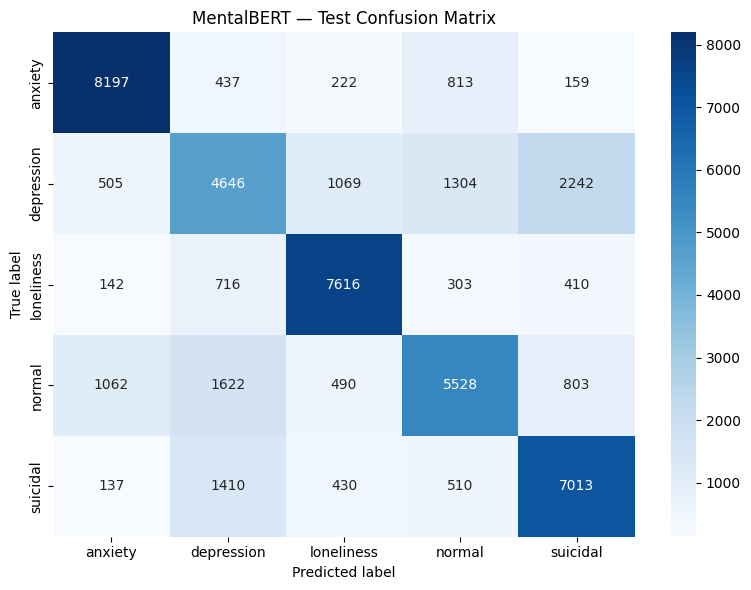

✓ Saved: /kaggle/working/figures/mentalbert_test_confusion_matrix.png


In [32]:
test_preds, test_true = get_predictions(final_trainer, test_dataset)
test_macro_f1 = f1_score(test_true, test_preds, average="macro")

print("=== FINAL TEST SET RESULTS ===")
print(classification_report(test_true, test_preds, target_names=label_names_list))
print(f"Macro F1 (report this in your comparison table): {test_macro_f1:.4f}")

plot_confusion_matrix(
    test_true, test_preds, label_names_list,
    "MentalBERT — Test Confusion Matrix",
    os.path.join(FIGURES_DIR, "mentalbert_test_confusion_matrix.png")
)

In [33]:
results = {
    "model"      : "MentalBERT (fine-tuned)",
    "macro_f1"   : round(test_macro_f1, 4),
    "best_hp"    : best_run.hyperparameters,
    "label_names": LABEL_NAMES
}
with open(os.path.join(OUTPUT_DIR, "mentalbert_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"✓ Results saved to {OUTPUT_DIR}/mentalbert_results.json")
print(f"  Macro F1 : {test_macro_f1:.4f}")
print(f"  Best HP  : {best_run.hyperparameters}")

✓ Results saved to /kaggle/working/mentalbert/mentalbert_results.json
  Macro F1 : 0.6876
  Best HP  : {'learning_rate': 3.6953958501474775e-05, 'weight_decay': 0.044648967619087127}


In [34]:
print("=== ALL OPTUNA TRIALS ===")
print(f"{'Trial':>5} {'Val F1':>8} {'LR':>10} {'Weight Decay':>13}")
print("─" * 40)

try:
    study = tuning_trainer.hp_search_backend.study
    for trial in sorted(study.trials, key=lambda t: t.value or 0, reverse=True):
        p = trial.params
        print(
            f"{trial.number:>5} "
            f"{trial.value:>8.4f} "
            f"{p.get('learning_rate', 0):>10.2e} "
            f"{p.get('weight_decay', 0):>13.4f}"
        )
except Exception:
    print(f"Best hyperparameters: {best_run.hyperparameters}")

=== ALL OPTUNA TRIALS ===
Trial   Val F1         LR  Weight Decay
────────────────────────────────────────
Best hyperparameters: {'learning_rate': 3.6953958501474775e-05, 'weight_decay': 0.044648967619087127}


In [35]:
def predict_text(text, model, tokenizer, label_names, max_len=MAX_LEN):
    model.eval()
    model.to(DEVICE)
    encoding = tokenizer(
        text, max_length=max_len, truncation=True,
        padding="max_length", return_tensors="pt"
    )
    with torch.no_grad():
        outputs = model(
            input_ids=encoding["input_ids"].to(DEVICE),
            attention_mask=encoding["attention_mask"].to(DEVICE)
        )
    probs     = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    pred_idx  = np.argmax(probs)
    pred_label = label_names.get(int(pred_idx), f"class_{pred_idx}")

    display = text[:80] + "..." if len(text) > 80 else text
    print(f"Text     : {display}")
    print(f"Predicted: {pred_label} ({probs[pred_idx]*100:.1f}% confidence)")
    print("All probabilities:")
    for i, prob in enumerate(probs):
        bar = "█" * int(prob * 30)
        print(f"  {label_names.get(i, f'class_{i}'):<12}: {bar:<30} {prob*100:.1f}%")
    print()
    return pred_label, probs


examples = [
    "I haven't left my room in days, nothing feels worth it anymore",
    "My heart keeps racing and I can't stop worrying about everything",
    "Had a great day today, feeling really good about things",
]

print("=== INFERENCE EXAMPLES ===")
for ex in examples:
    predict_text(ex, final_trainer.model, tokenizer, LABEL_NAMES)

=== INFERENCE EXAMPLES ===
Text     : I haven't left my room in days, nothing feels worth it anymore
Predicted: depression (77.0% confidence)
All probabilities:
  anxiety     :                                1.2%
  depression  : ███████████████████████        77.0%
  loneliness  : █                              4.7%
  normal      : █                              6.1%
  suicidal    : ███                            11.0%

Text     : My heart keeps racing and I can't stop worrying about everything
Predicted: anxiety (95.2% confidence)
All probabilities:
  anxiety     : ████████████████████████████   95.2%
  depression  :                                1.0%
  loneliness  :                                0.1%
  normal      : █                              3.4%
  suicidal    :                                0.2%

Text     : Had a great day today, feeling really good about things
Predicted: loneliness (29.1% confidence)
All probabilities:
  anxiety     : █████                          17.8%
 